# Notebook 1 — Data Collection & Exploration
**Project:** Job Offer Scam Detection  
**Student:** Mohamed Baounna — SIIA S6  
**Professor:** Pr. H. El Hamdaoui

---

## Objectives
- Load the EMSCAD dataset (Employment Scam Aegean Dataset)
- Understand class distribution
- Visualize key features: text length, word clouds, missing values
- Derive insights that justify our preprocessing choices

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/raw/fake_job_postings.csv'
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Download

The dataset is the **EMSCAD** (Employment Scam Aegean Dataset), available on Kaggle.

**Download steps:**
```bash
pip install kaggle
# Place your kaggle.json API token in ~/.kaggle/kaggle.json
kaggle datasets download -d whenamancodes/real-or-fake-jobs -p ../data/raw --unzip
```

Or manually download from:  
https://www.kaggle.com/datasets/whenamancodes/real-or-fake-jobs

> If the dataset is not available, a synthetic dataset will be generated for demonstration.

In [2]:
def make_synthetic_dataset(n=500, seed=42):
    """Generate a small synthetic dataset for demonstration when Kaggle data is unavailable."""
    rng = np.random.default_rng(seed)
    legit_titles = [
        'Software Engineer', 'Data Scientist', 'Product Manager', 'UX Designer',
        'DevOps Engineer', 'Backend Developer', 'Frontend Developer', 'ML Engineer'
    ]
    fraud_titles = [
        'Work From Home – Earn $5000/week!', 'No Experience Needed – Unlimited Income',
        'Urgent! Start Today – High Pay', 'Online Job – Easy Money Fast'
    ]
    legit_desc = (
        "We are looking for a skilled professional to join our team. "
        "You will collaborate with cross-functional teams, write clean code, "
        "and contribute to product development. Competitive salary and benefits provided."
    )
    fraud_desc = (
        "Amazing opportunity! Work from home, no experience required. "
        "Earn up to $5000 per week! Send your personal details to get started immediately. "
        "Limited slots available – act now! No interview needed."
    )
    rows = []
    for i in range(n):
        is_fraud = 1 if rng.random() < 0.15 else 0
        rows.append({
            'title': rng.choice(fraud_titles if is_fraud else legit_titles),
            'company_profile': '' if (is_fraud and rng.random() < 0.6) else 'A reputable company founded in 2010.',
            'description': fraud_desc if is_fraud else legit_desc,
            'requirements': '' if is_fraud else 'Bachelor degree, 2+ years experience, Python skills.',
            'benefits': 'Unlimited earnings!' if is_fraud else 'Health insurance, 401k, remote work.',
            'fraudulent': is_fraud
        })
    return pd.DataFrame(rows)

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
else:
    print('Dataset not found. Generating synthetic dataset for demonstration...')
    df = make_synthetic_dataset(n=500)
    os.makedirs('../data/raw', exist_ok=True)
    df.to_csv(DATA_PATH, index=False)
    print(f'Synthetic dataset created: {df.shape[0]} rows × {df.shape[1]} columns')

df.head(3)

Dataset loaded: 17,880 rows × 18 columns


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


## 2. Basic Statistics

In [3]:
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nSample fraudulent label counts:')
print(df['fraudulent'].value_counts())

Shape: (17880, 18)

Column types:
job_id                 int64
title                    str
location                 str
department               str
salary_range             str
company_profile          str
description              str
requirements             str
benefits                 str
telecommuting          int64
has_company_logo       int64
has_questions          int64
employment_type          str
required_experience      str
required_education       str
industry                 str
function                 str
fraudulent             int64
dtype: object

Sample fraudulent label counts:
fraudulent
0    17014
1      866
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,17880.0,NaN,NaN,NaN,8940.5,5161.655742,1.0,4470.75,8940.5,13410.25,17880.0
title,17880,11231,English Teacher Abroad,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,17534,3105,"GB, LND, London",718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,6333,1337,Sales,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_range,2868,874,0-0,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_profile,14572,1709,We help teachers get safe &amp; secure jobs ab...,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,17879,14801,"Play with kids, get paid for it Love travel? J...",379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requirements,15184,11967,University degree required. TEFL / TESOL / CEL...,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefits,10668,6204,See job description,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telecommuting,17880.0,NaN,NaN,NaN,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0


## 3. Class Distribution

The dataset is **heavily imbalanced**: approximately 95% legitimate and 5% fraudulent postings. This is important — it means accuracy alone is a misleading metric, and we will favour **F1-Score** and **ROC-AUC**.

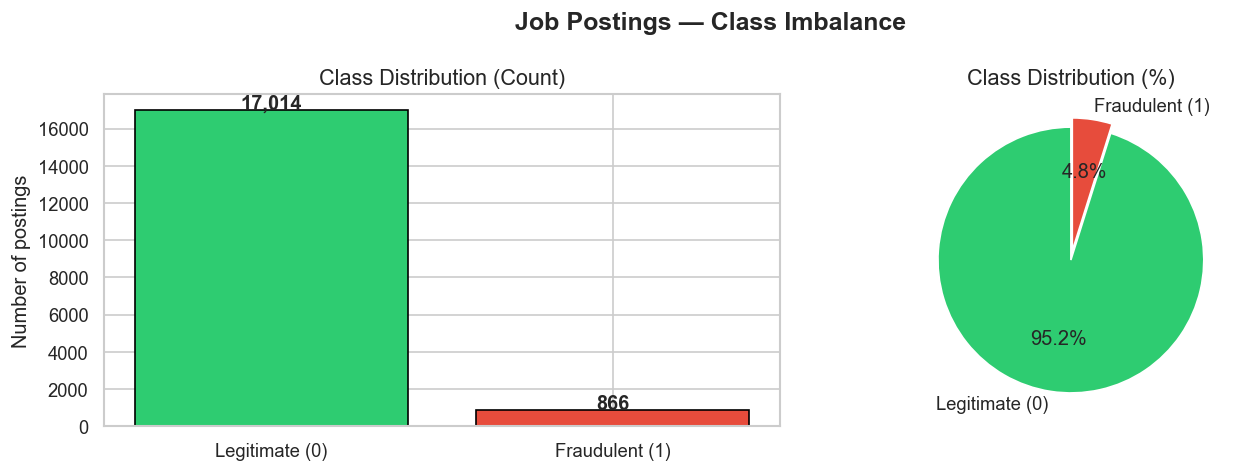


Fraudulent: 866 (4.8%)
Legitimate: 17,014 (95.2%)

Imbalance ratio: 1:19


In [5]:
counts = df['fraudulent'].value_counts()
labels = ['Legitimate (0)', 'Fraudulent (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, [counts[0], counts[1]], color=['#2ecc71', '#e74c3c'], edgecolor='black')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of postings')

# Pie chart
axes[1].pie(
    [counts[0], counts[1]],
    labels=labels,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.07)
)
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('Job Postings — Class Imbalance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', bbox_inches='tight')
plt.show()

fraud_pct = counts[1] / counts.sum() * 100
print(f'\nFraudulent: {counts[1]:,} ({fraud_pct:.1f}%)')
print(f'Legitimate: {counts[0]:,} ({100-fraud_pct:.1f}%)')
print(f'\nImbalance ratio: 1:{counts[0]//max(counts[1],1)}')

## 4. Missing Value Analysis

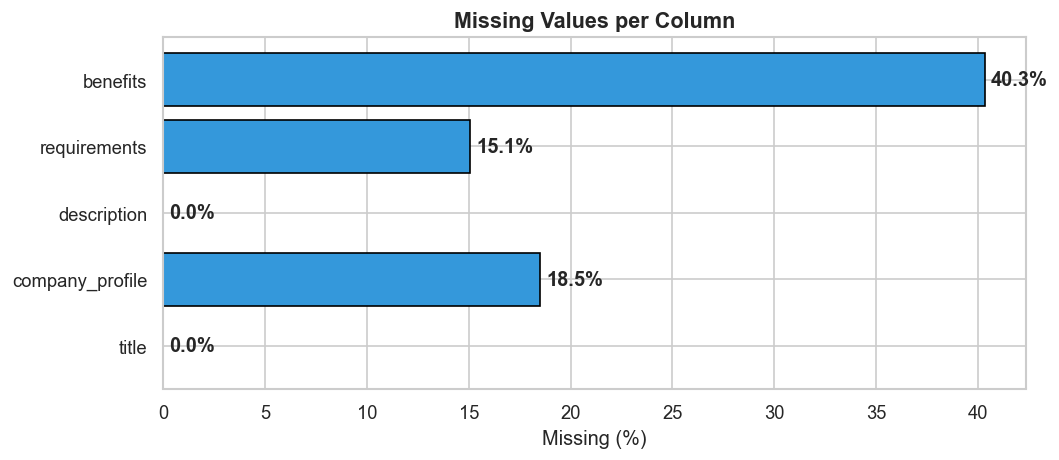

                 Missing Count  Missing %
title                        0       0.00
company_profile           3308      18.50
description                  1       0.01
requirements              2696      15.08
benefits                  7212      40.34


In [6]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']

missing = pd.DataFrame({
    'Missing Count': df[text_cols].isnull().sum(),
    'Missing %': (df[text_cols].isnull().mean() * 100).round(2)
})

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing.index, missing['Missing %'], color='#3498db', edgecolor='black')
for bar, val in zip(bars, missing['Missing %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Column', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/missing_values.png', bbox_inches='tight')
plt.show()
print(missing)

## 5. Text Length Distribution

We compare the length of the `description` column for legitimate vs fraudulent postings.  
Fraudulent postings tend to be **shorter and vaguer**.

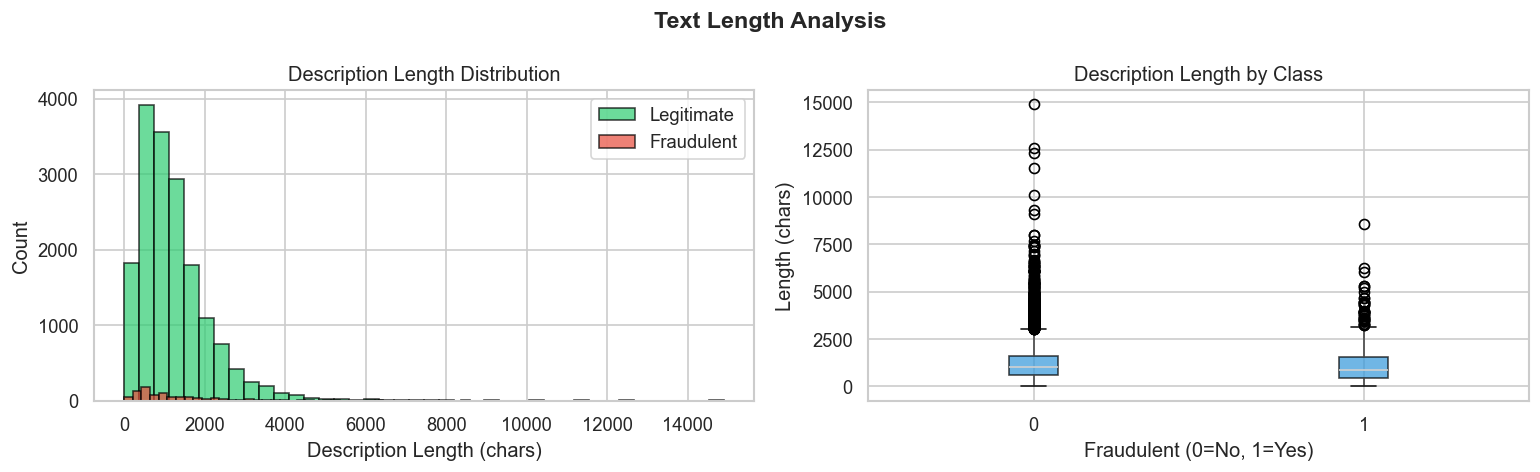

Mean description length:
fraudulent
Legitimate    1221.219701
Fraudulent    1154.834873
Name: desc_len, dtype: float64


In [7]:
df['desc_len'] = df['description'].fillna('').apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraudulent')]:
    subset = df[df['fraudulent'] == label]['desc_len']
    axes[0].hist(subset, bins=40, alpha=0.7, color=color, label=name, edgecolor='black')

axes[0].set_xlabel('Description Length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Description Length Distribution')
axes[0].legend()

df.boxplot(column='desc_len', by='fraudulent', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Description Length by Class')
axes[1].set_xlabel('Fraudulent (0=No, 1=Yes)')
axes[1].set_ylabel('Length (chars)')
plt.suptitle('Text Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/text_length_distribution.png', bbox_inches='tight')
plt.show()

print('Mean description length:')
print(df.groupby('fraudulent')['desc_len'].mean().rename({0: 'Legitimate', 1: 'Fraudulent'}))

## 6. Word Clouds

Word clouds reveal the most frequent words in each class.  
Scam postings often contain words like *earn*, *home*, *urgent*, *free*, *income*, *daily*.

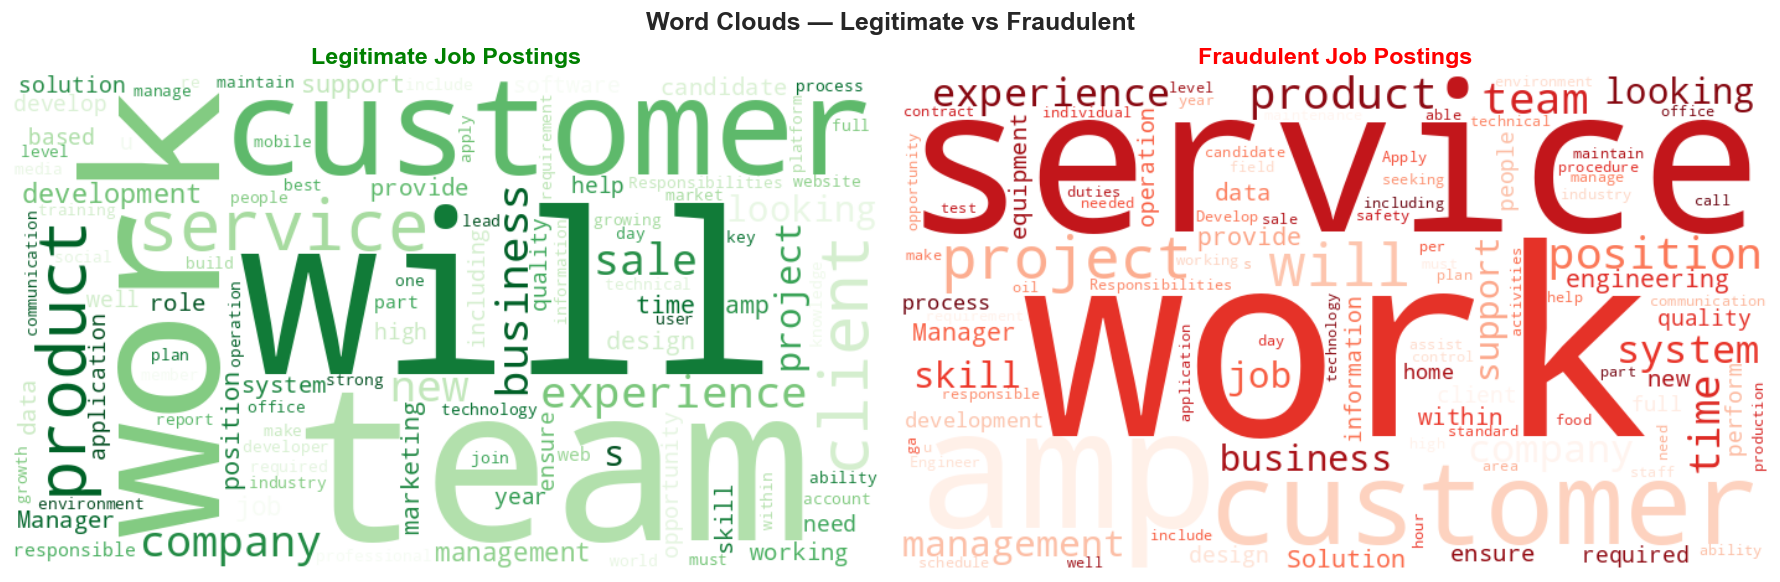

In [8]:
from wordcloud import WordCloud

legit_text = ' '.join(df[df['fraudulent'] == 0]['description'].fillna(''))
fraud_text = ' '.join(df[df['fraudulent'] == 1]['description'].fillna(''))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

wc_legit = WordCloud(
    width=700, height=400, background_color='white',
    colormap='Greens', max_words=100, collocations=False
).generate(legit_text)

wc_fraud = WordCloud(
    width=700, height=400, background_color='white',
    colormap='Reds', max_words=100, collocations=False
).generate(fraud_text)

axes[0].imshow(wc_legit, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Legitimate Job Postings', fontsize=14, fontweight='bold', color='green')

axes[1].imshow(wc_fraud, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Fraudulent Job Postings', fontsize=14, fontweight='bold', color='red')

plt.suptitle('Word Clouds — Legitimate vs Fraudulent', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/wordclouds.png', bbox_inches='tight')
plt.show()

## 7. Top Unigrams per Class

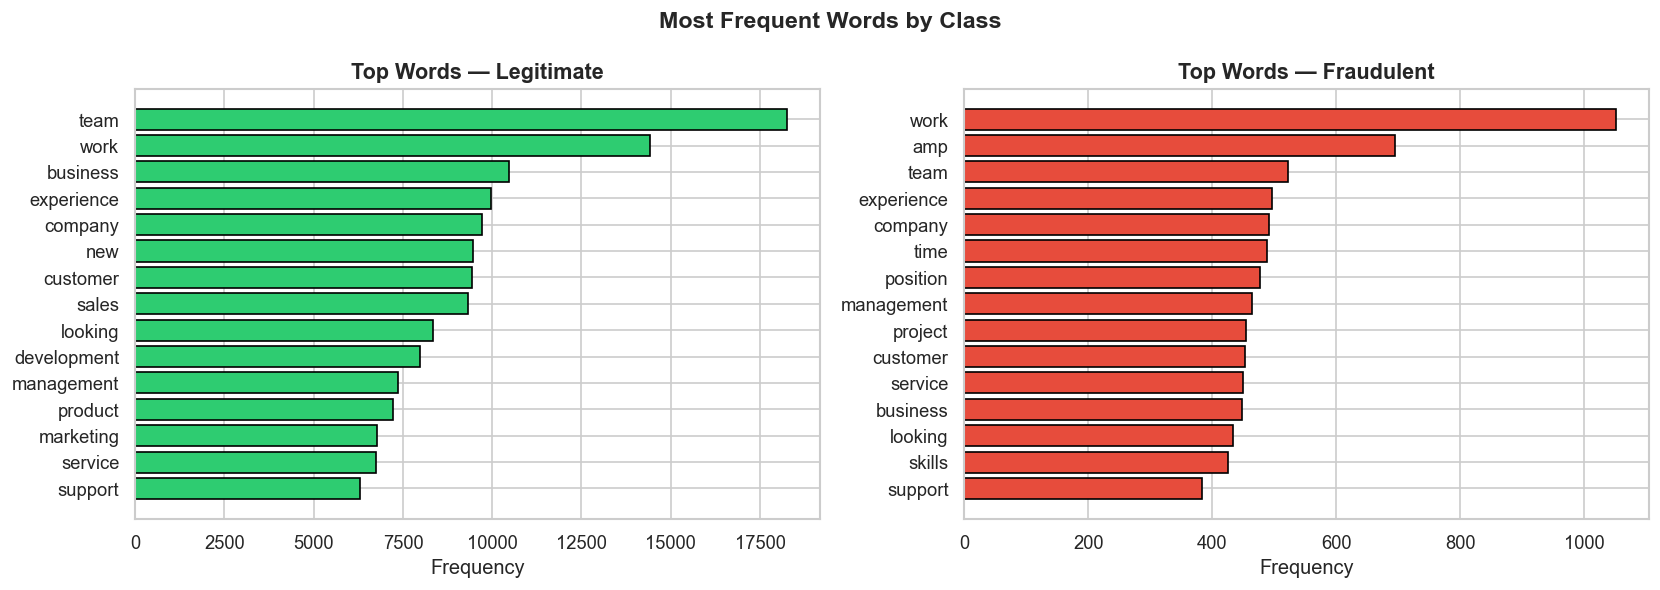

In [9]:
from collections import Counter
import re

STOPWORDS = {'the','a','an','and','or','of','to','in','for','is','are','be','with',
             'that','this','will','we','our','your','you','have','has','all','on','at',
             'as','by','from','it','its','not','but','can','more','their','they','i',
             'if','about','which','was','were','been','would','should','may','also'}

def top_words(text, n=15):
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    words = [w for w in words if w not in STOPWORDS]
    return Counter(words).most_common(n)

top_legit = top_words(legit_text)
top_fraud = top_words(fraud_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words_l, counts_l = zip(*top_legit)
axes[0].barh(words_l[::-1], counts_l[::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top Words — Legitimate', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

words_f, counts_f = zip(*top_fraud)
axes[1].barh(words_f[::-1], counts_f[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Words — Fraudulent', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/top_words.png', bbox_inches='tight')
plt.show()

## 8. Key Observations & Conclusions

| Observation | Impact on Pipeline |
|-------------|-------------------|
| **~5% fraud rate** — severe class imbalance | Use `class_weight='balanced'` in models; prefer F1/AUC metrics |
| **High missing values** in `company_profile`, `requirements`, `benefits` | Fill NaN with empty string before combining |
| **Fraudulent posts are shorter** | Description length is a useful feature (already captured by TF-IDF) |
| **Distinct vocabulary** — fraud uses hypey words | TF-IDF will naturally assign high weight to discriminative scam terms |

> **Next:** Notebook 2 — Text Preprocessing